In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import FeatureUnion, Pipeline



In [2]:

#--- 1. LOAD LOCAL CSV DATA ---
# Replace with the actual path to your files
path = "datasets" 

try:
    train_df = pd.read_csv(f"{path}/arabic_dialects_train.csv")
    dev_df = pd.read_csv(f"{path}/arabic_dialects_dev.csv")
    test_df = pd.read_csv(f"{path}/arabic_dialects_test.csv")
    
    df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
    
    # 1. Print columns to help you see exactly what's inside
    print("Column names found in your files:", df.columns.tolist())
    
    # 2. Try to map common names
    if 'Sentence' in df.columns:
        text_col, target_col = 'Sentence', 'Region'
    elif 'text' in df.columns:
        text_col, target_col = 'text', 'label'
    else:
        # 3. Fallback: Use the first and second columns if the names are unknown
        # Usually, col 0 is the text and col 1 is the dialect
        text_col = df.columns[0]
        target_col = df.columns[1]
        print(f"⚠️ Column names didn't match. Defaulting to: Text='{text_col}', Label='{target_col}'")
    
    print(f"Successfully loaded {len(df)} total rows.")

except Exception as e:
    print(f"Error loading files: {e}")
    raise


Column names found in your files: ['sentence', 'dialect']
⚠️ Column names didn't match. Defaulting to: Text='sentence', Label='dialect'
Successfully loaded 10102 total rows.


Overall Accuracy: 0.7655

Dialect-Level Report:
               precision    recall  f1-score   support

         EGY       0.96      0.91      0.93       812
         GLF       0.60      0.59      0.59       335
         LAV       0.69      0.60      0.64       352
         MSA       0.70      0.82      0.75       200
         NOR       0.63      0.74      0.68       322

    accuracy                           0.77      2021
   macro avg       0.71      0.73      0.72      2021
weighted avg       0.77      0.77      0.77      2021



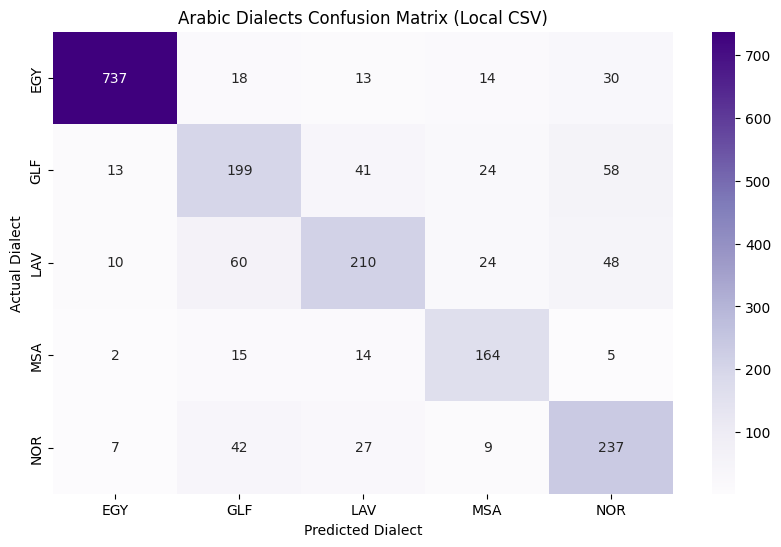

In [4]:

# --- 2. ARABIC NORMALIZATION ---
def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[\u064B-\u0652]", "", text) # Remove diacritics
    text = re.sub(r"[أإآ]", "ا", text)           # Normalize Alif
    text = re.sub(r"ى", "ي", text)              # Normalize Yeh
    text = re.sub(r"ة", "ه", text)              # Normalize Teh Marbuta
    text = re.sub(r"[^\u0621-\u064A\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- 3. PIPELINE ---
df['text_clean'] = df[text_col].apply(normalize_arabic)

# Keep the sampling logic to maintain consistency
# df_sampled = df.groupby(target_col).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42)).reset_index(drop=True)
df_sampled = df.sample(frac=1, random_state=42).groupby(target_col, group_keys=False).head(5000).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_sampled['text_clean'], 
    df_sampled[target_col], 
    test_size=0.2, 
    stratify=df_sampled[target_col],
    random_state=42
)

# Define the Hybrid Feature Union
# We use 'char_wb' which is more robust as it doesn't cross word boundaries
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=25000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Use Logistic Regression with the new massive feature set
model = LogisticRegression(max_iter=1500, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# --- 4. EVALUATION ---
y_pred = model.predict(X_test_tfidf)
labels = sorted(df_sampled[target_col].unique())

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDialect-Level Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Purples')
plt.title('Arabic Dialects Confusion Matrix (Local CSV)')
plt.ylabel('Actual Dialect')
plt.xlabel('Predicted Dialect')
plt.show()
